In [1]:
from google.colab import files
uploaded = files.upload()

Saving StudentsPerformance.csv to StudentsPerformance.csv


In [2]:
import pandas as pd
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

In [4]:
X = df[['math score']]
y = df['writing score']

model = LinearRegression()
model.fit(X,y)

pred = model.predict(X)

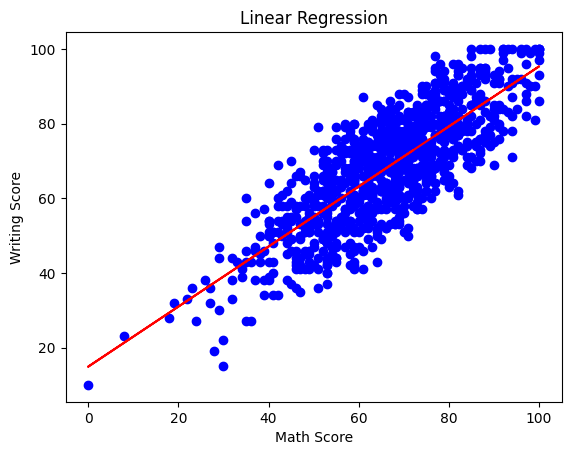

In [5]:
plt.scatter(X,y,color='blue')
plt.plot(X,pred,color='red')
plt.xlabel("Math Score")
plt.ylabel("Writing Score")
plt.title("Linear Regression")
plt.show()

In [6]:
X_multi = df[['math score','reading score']]
y_multi = df['writing score']

multi_model = LinearRegression()
multi_model.fit(X_multi,y_multi)

print("Math coefficient:",multi_model.coef_[0])
print("Reading coefficient:",multi_model.coef_[1])

Math coefficient: 0.06704516117851397
Reading coefficient: 0.9366030543321231


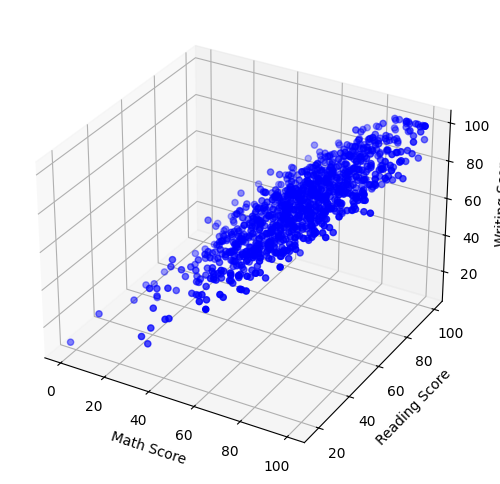

In [7]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['math score'], df['reading score'], df['writing score'], color='blue')

ax.set_xlabel('Math Score')
ax.set_ylabel('Reading Score')
ax.set_zlabel('Writing Score')

plt.show()

In [8]:
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv"
df = pd.read_csv(url)

df = df[['carat','price']].sample(200, random_state=42)
df.head()

,carat,price
1388,0.24,559
50052,0.58,2201
41645,0.40,1238
42377,0.43,1304
17244,1.55,6901


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


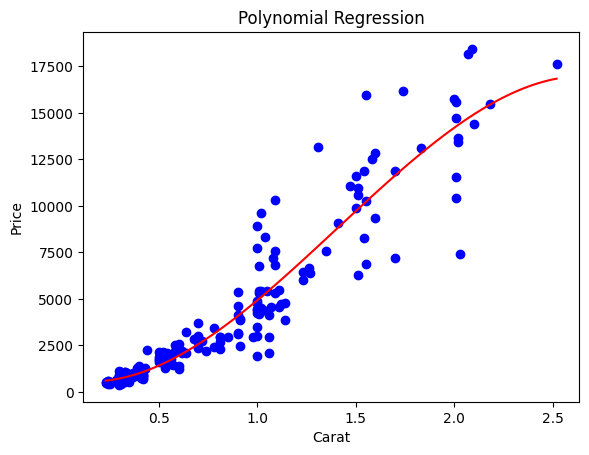

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

X = df[['carat']]
y = df['price']

poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly,y)

X_range = np.linspace(X.min(),X.max(),100)
X_range_poly = poly.transform(X_range)

y_pred = model.predict(X_range_poly)

plt.scatter(X,y,color='blue')
plt.plot(X_range,y_pred,color='red')
plt.xlabel("Carat")
plt.ylabel("Price")
plt.title("Polynomial Regression")
plt.show()